In [3]:
# Cell 1: Local Configuration Environment
class CatalogConfig:
    # Source file descriptor
    DATA_PATH = "netflixData.csv"
    
    # Randomization standard
    RANDOM_SEED = 42
    
    # Visualization preferences
    TOP_GENRES_LIMIT = 10
    PRIMARY_PALETTE = "magma"
    SECONDARY_PALETTE = "rocket"

config = CatalogConfig()
print("🎯 Netflix Catalog Engine Parameters Configured Safely!")

🎯 Netflix Catalog Engine Parameters Configured Safely!


In [5]:
# Cell 2: Data Cleaning & Parsing Pipeline
import pandas as pd
import numpy as np

def load_and_clean_catalog():
    print(f"📡 Ingesting source dataset from: {config.DATA_PATH}...")
    df = pd.read_csv(config.DATA_PATH)
    
    print("🧹 Executing column profiling and structural imputation...")
    
    # 1. Handle missing critical parameters
    df['Rating'] = df['Rating'].fillna('TV-MA')
    df['Release Date'] = df['Release Date'].fillna(df['Release Date'].median())
    
    # 2. Parse text string scores (e.g., '6.6/10') into high-precision floats
    df['Imdb_Score_Cleaned'] = df['Imdb Score'].astype(str).str.split('/').str[0]
    df['Imdb_Score_Cleaned'] = pd.to_numeric(df['Imdb_Score_Cleaned'], errors='coerce')
    
    # Impute missing IMDb scores with the dataset median
    df['Imdb_Score_Cleaned'] = df['Imdb_Score_Cleaned'].fillna(df['Imdb_Score_Cleaned'].median())
    
    # 3. Extract purely numerical tracking metrics from the messy text 'Duration' column
    df['Duration_Numerical'] = df['Duration'].astype(str).str.extract(r'(\d+)').astype(float)
    df['Duration_Numerical'] = df['Duration_Numerical'].fillna(0)
    
    print(f"✅ Cleansing complete! Active rows processed: {df.shape[0]}")
    return df

# Execute initialization layer
df_netflix = load_and_clean_catalog()

📡 Ingesting source dataset from: netflixData.csv...
🧹 Executing column profiling and structural imputation...
✅ Cleansing complete! Active rows processed: 5967


In [6]:
# Cell 3: Text Unnesting & Content Categorization
def unnest_catalog_genres(df):
    print("✨ Unnesting combined categorical string lists...")
    
    # Split comma-separated genre elements into true lists, then explode into separate records
    genre_series = df['Genres'].str.split(', ')
    df_exploded = df.assign(Genre_Isolated=genre_series).explode('Genre_Isolated')
    
    # Compute true, un-biased frequency counts
    top_genres = df_exploded['Genre_Isolated'].value_counts().head(config.TOP_GENRES_LIMIT)
    
    print("✅ Categorical extraction layer finalized!")
    return df_exploded, top_genres

# Execute text manipulation layer
df_exploded_genres, top_genres_series = unnest_catalog_genres(df_netflix)

✨ Unnesting combined categorical string lists...
✅ Categorical extraction layer finalized!


📊 Generating high-fidelity trend graphic dashboards...


/var/folders/qs/t2124lzd51n4crc485v38zjc0000gn/T/ipykernel_11118/3835712061.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


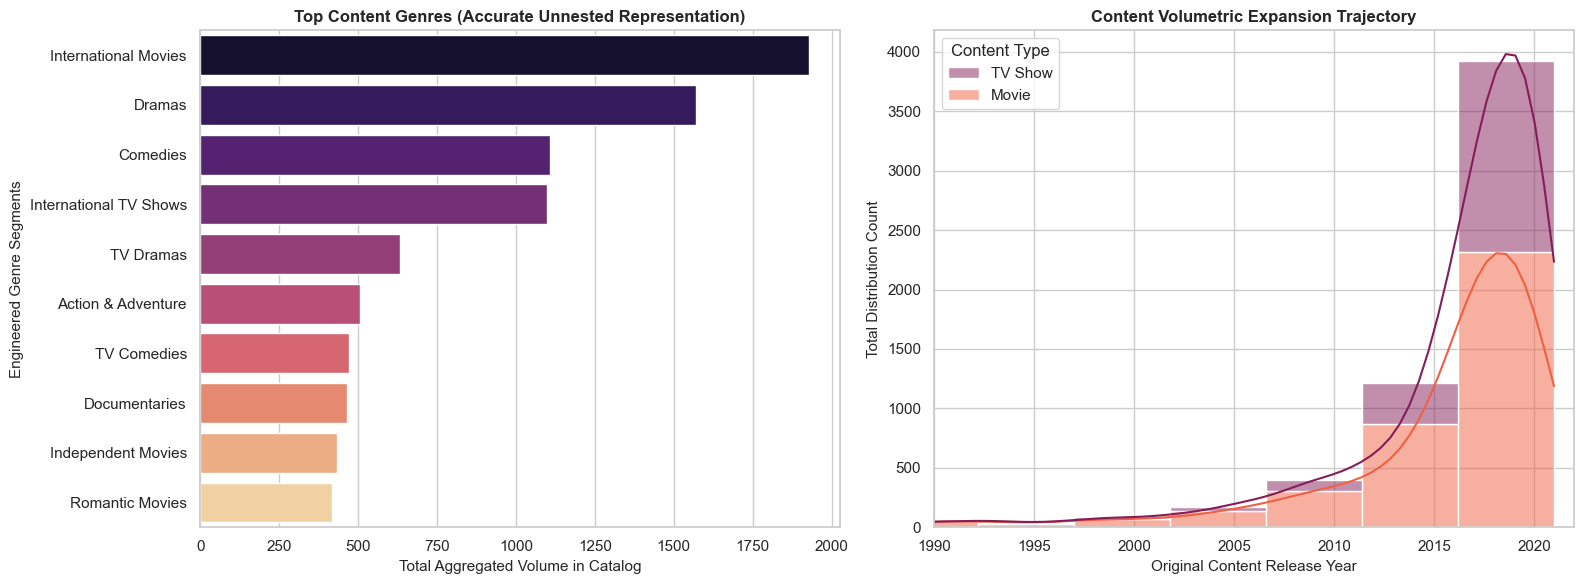

In [7]:
# Cell 4: Content Strategy Visualization Dashboard
import matplotlib.pyplot as plt
import seaborn as sns

def generate_catalog_dashboards(df, top_genres):
    print("📊 Generating high-fidelity trend graphic dashboards...")
    sns.set_theme(style="whitegrid")
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graph 1: Top Unnested Catalog Genres Distribution
    sns.barplot(
        x=top_genres.values, 
        y=top_genres.index, 
        ax=ax[0], 
        palette=config.PRIMARY_PALETTE
    )
    ax[0].set_title('Top Content Genres (Accurate Unnested Representation)', fontsize=12, weight='bold')
    ax[0].set_xlabel('Total Aggregated Volume in Catalog', fontsize=11)
    ax[0].set_ylabel('Engineered Genre Segments', fontsize=11)
    
    # Graph 2: Volumetric Production Trends over time (Grouped by content format type)
    sns.histplot(
        data=df, 
        x='Release Date', 
        hue='Content Type', 
        multiple='stack', 
        ax=ax[1], 
        palette=config.SECONDARY_PALETTE,
        bins=20,
        kde=True
    )
    ax[1].set_title('Content Volumetric Expansion Trajectory', fontsize=12, weight='bold')
    ax[1].set_xlabel('Original Content Release Year', fontsize=11)
    ax[1].set_ylabel('Total Distribution Count', fontsize=11)
    ax[1].set_xlim([1990, 2022])  # Focus on modern streaming development era
    
    plt.tight_layout()
    plt.show()

# Execute reporting graphics layer
generate_catalog_dashboards(df_netflix, top_genres_series)